In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm
from scipy import stats

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Configuration and paths
mac = 20
pheno_list_type = None
# pheno_list_type = 'biochemistry'
# pheno_list_type = 'overall_phenotype'

new_anno_df_path = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds_categories.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""genomic_region""","""mane_cds""","""#E31A1C""","""MANE CDS""",1
"""genomic_region""","""non_mane_cds""","""#FB9A99""","""Other CDS""",1
"""genomic_region""","""mane_exonic""","""#33A02C""","""MANE Exon""",1
"""genomic_region""","""non_mane_exonic""","""#B2DF8A""","""Other Exon""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
…,…,…,…,…
"""encode_enhancer""","""encode_ca_ctcf""","""#4DAF4A""","""Accessible Region with CTCF Bi…",1
"""encode_enhancer""","""encode_ca""","""#377EB8""","""Chromatin Accessible""",1
"""encode_enhancer""","""encode_ca_tf""","""#1D6498""","""Accessible Region with TF Bind…",1


In [3]:
anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True)
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        # (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(existing_annos))
        # .union(set(plof_cols))
    )
    .with_columns(
        start_stop_lost = (pl.col('consequence_start_lost') == 1) | (pl.col('consequence_stop_lost') == 1)
    )
    .collect(engine='streaming')
)

anno

consequence_stop_lost,encode_tf,encode_dels,five_prime_utr_variant_consequence_uaug_lost,mobi_lip_full,low_complexity_domain,mane_exonic,non_mane_exonic,ted_domain,consequence_start_lost,encode_ca_h3k4me3,loftee_hc,consequence_splice_acceptor_variant,consequence_missense_variant,non_mane_cds,mobi_curated_disorder_priority,not_in_encode,five_prime_utr_variant_consequence_uframeshift,five_prime_utr_variant_consequence_uaug_gained,five_prime_utr_variant_consequence_ustop_gained,loftee_lc,gene_name,five_prime_utr_variant_consequence_ustop_lost,consequence_frameshift_variant,encode_pels,region,encode_ca_ctcf,encode_ca_tf,consequence_stop_gained,id,consequence_splice_donor_variant,encode_ca,mane_cds,encode_pls,start_stop_lost
i32,bool,bool,u8,bool,bool,bool,bool,bool,i32,bool,i8,i32,i32,bool,bool,bool,u8,u8,u8,i8,str,u8,i32,bool,str,bool,bool,i32,str,i32,bool,bool,bool,bool
0,false,true,0,true,false,true,false,false,0,false,0,0,1,false,false,false,0,0,0,0,"""PLEKHO2""",0,0,false,"""ENSG00000241839""",false,false,0,"""chr15:64859998:G:C""",0,false,true,false,false
0,false,false,0,true,true,true,false,false,0,false,0,0,1,false,true,true,0,0,0,0,"""KDM5B""",0,0,false,"""ENSG00000117139""",false,false,0,"""chr1:202729885:A:T""",0,false,true,false,false
0,false,false,0,false,false,true,false,true,0,false,0,0,1,false,false,true,0,0,0,0,"""ACRV1""",0,0,false,"""ENSG00000134940""",false,false,0,"""chr11:125672628:A:G""",0,false,true,false,false
0,false,true,0,false,false,true,false,false,0,false,0,0,1,false,false,false,0,0,0,0,"""KDM5B""",0,0,false,"""ENSG00000117139""",false,false,0,"""chr1:202742800:C:T""",0,false,true,false,false
0,false,false,0,false,false,true,false,false,0,false,0,0,1,false,true,true,0,0,0,0,"""KDM5B""",0,0,false,"""ENSG00000117139""",false,false,0,"""chr1:202735550:A:G""",0,false,true,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,false,true,0,false,false,true,false,true,0,false,1,0,0,false,false,false,0,0,0,0,"""HDAC1""",0,1,false,"""ENSG00000116478""",false,false,0,"""chr1:32316756:C:CG""",0,false,true,false,false
0,false,false,0,false,false,true,false,false,0,false,1,0,0,false,false,true,0,0,0,0,"""RTTN""",0,1,false,"""ENSG00000176225""",false,false,0,"""chr18:70020738:CAG:C""",0,false,true,false,false
0,false,false,0,false,false,true,false,true,0,false,0,0,0,false,false,true,0,0,0,0,"""CHEK2""",0,0,false,"""ENSG00000183765""",false,false,0,"""chr22:28703536:CAAA:C""",0,false,true,false,false


In [4]:
# selected_annos = anno_config_df.filter(
#     pl.col('category').is_in(['plof_consequences']) # plof consequences
# )['annotation'].to_list()

selected_annos = ['consequence_stop_lost', 'consequence_start_lost', 'consequence_splice_donor_variant', 'loftee_hc', 'consequence_splice_acceptor_variant', 'loftee_lc', 'consequence_stop_gained', 'consequence_frameshift_variant', 'consequence_missense_variant']

melted_anno = (
    anno

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]),
        on="annotation",
        how="left"
    )
    .with_columns(
        # annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir")
        annotation_score_dircor = (
            pl.when(pl.col("annotation_dir")!=1)
            .then((pl.col('annotation_score')-1).abs())
            .otherwise(pl.col('annotation_score'))
        )
    )
    
    .filter(
        (pl.col('annotation_score') != 0)
    )
)

melted_anno

id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor
str,str,str,f32,str,i8,f32
"""chr20:3804961:A:G""","""ENSG00000101224""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
"""chr16:2037982:T:C""","""ENSG00000065054""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
"""chr14:32154946:T:G""","""ENSG00000100852""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
"""chr3:52524355:G:T""","""ENSG00000010327""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
"""chr3:52524354:T:C""","""ENSG00000010327""","""consequence_stop_lost""",1.0,"""plof_consequences""",1,1.0
…,…,…,…,…,…,…
"""chr17:39715823:C:T""","""ENSG00000141736""","""consequence_missense_variant""",1.0,"""missense""",1,1.0
"""chr10:99819216:C:A""","""ENSG00000023839""","""consequence_missense_variant""",1.0,"""missense""",1,1.0
"""chr10:99800490:A:T""","""ENSG00000023839""","""consequence_missense_variant""",1.0,"""missense""",1,1.0


In [5]:
# Get gene trait associations

plof = pl.read_parquet('/home/dnanexus/data_dir/association_files/rvat_EUR_500k_regenie.parquet').with_columns(
    phenotype = (pl.col('trait') + '_int'),
    region = pl.col('gene_id'),
    rvat_pval = (10** -pl.col("neg_log10p")),
).filter(
    (pl.col('trait_type') == 'quantitative')
)

loftee_corr = pl.read_parquet("/home/dnanexus/data_dir/association_files/loftee_correlation_quantitative_wgs_EUR_genebass1e6_maf1e3_snp_consistent.parquet")

gene_trait_df = loftee_corr.join(plof[['region', 'phenotype', 'beta', 'rvat_pval']], on=['region', 'phenotype'], how='inner').filter(
    pl.col('loftee_corr')*pl.col('beta') > 0
).with_columns(
    corr_dir = pl.col('loftee_corr')/pl.col('loftee_corr').abs()
)
gene_trait_df

region,gene_name,phenotype,loftee_corr,n_variants,beta,rvat_pval,corr_dir
str,str,str,f64,u64,f64,f64,f64
"""ENSG00000116183""","""PAPPA2""","""arm_fatfree_mass_right_int""",-0.014747,82603,-0.195409,9.1637e-8,-1.0
"""ENSG00000129083""","""COPB1""","""arm_fatfree_mass_right_int""",-0.014338,13594,-0.397279,0.006626,-1.0
"""ENSG00000100578""","""KIAA0586""","""arm_fatfree_mass_right_int""",-0.010787,28541,-0.058463,0.000305,-1.0
"""ENSG00000157766""","""ACAN""","""arm_fatfree_mass_right_int""",-0.036259,20244,-0.436618,6.0395e-11,-1.0
"""ENSG00000140443""","""IGF1R""","""arm_fatfree_mass_right_int""",-0.013644,82469,-0.412619,2.8609e-8,-1.0
…,…,…,…,…,…,…,…
"""ENSG00000112077""","""RHAG""","""reticulocyte_count_int""",0.033239,9849,0.952411,1.8038e-41,1.0
"""ENSG00000029534""","""ANK1""","""reticulocyte_count_int""",0.02685,54620,0.656849,2.1682e-10,1.0
"""ENSG00000197969""","""VPS13A""","""reticulocyte_count_int""",0.003971,55477,0.176348,2.1188e-7,1.0


In [6]:
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr_with_percentiles.parquet")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

In [7]:
plof_pheno_df = (
    # A. Use a semi join for efficient filtering (more memory-safe than 'is_in')
    appv
    # B. Join the other two dataframes
    .join(
        melted_anno.lazy(),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df.lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .with_columns(
        mean_pheno_value_dircor = pl.col('mean_pheno_value')*pl.col('corr_dir')
    )
    
    # C. Group by annotation and aggregate
    .group_by(['annotation'])
    .agg(
        n_vars = pl.col('id').n_unique(),
        median_pheno = pl.col('mean_pheno_value_dircor').median(),
        mean_pheno = pl.col('mean_pheno_value_dircor').mean(),
        std_pheno = pl.col('mean_pheno_value_dircor').std(),
    )
    .with_columns(
        se_pheno = pl.col('std_pheno') / pl.col('n_vars').sqrt()
    )
    .with_columns(
        ci_low_pheno = pl.col('mean_pheno') - 1.96*pl.col('se_pheno'),
        ci_high_pheno = pl.col('mean_pheno') + 1.96*pl.col('se_pheno'),
    )
    .collect(engine='streaming')
)

plof_pheno_df

annotation,n_vars,median_pheno,mean_pheno,std_pheno,se_pheno,ci_low_pheno,ci_high_pheno
str,u64,f64,f64,f64,f64,f64,f64
"""loftee_hc""",18857,0.287814,0.344137,0.831615,0.006056,0.332267,0.356007
"""consequence_splice_acceptor_va…",1804,0.305418,0.356108,0.790514,0.018612,0.319629,0.392587
"""consequence_stop_lost""",126,0.142572,0.178621,0.684608,0.06099,0.059081,0.298161
"""consequence_frameshift_variant""",9561,0.263288,0.31925,0.85283,0.008722,0.302155,0.336345
"""consequence_splice_donor_varia…",2298,0.269925,0.335231,0.800861,0.016706,0.302487,0.367976
"""consequence_start_lost""",336,0.173848,0.209961,0.703343,0.03837,0.134754,0.285167
"""consequence_missense_variant""",165365,0.035417,0.051459,0.653202,0.001606,0.04831,0.054607
"""loftee_lc""",819,0.163905,0.211185,0.898156,0.031384,0.149672,0.272698
"""consequence_stop_gained""",6157,0.309577,0.363417,0.828738,0.010562,0.342717,0.384118


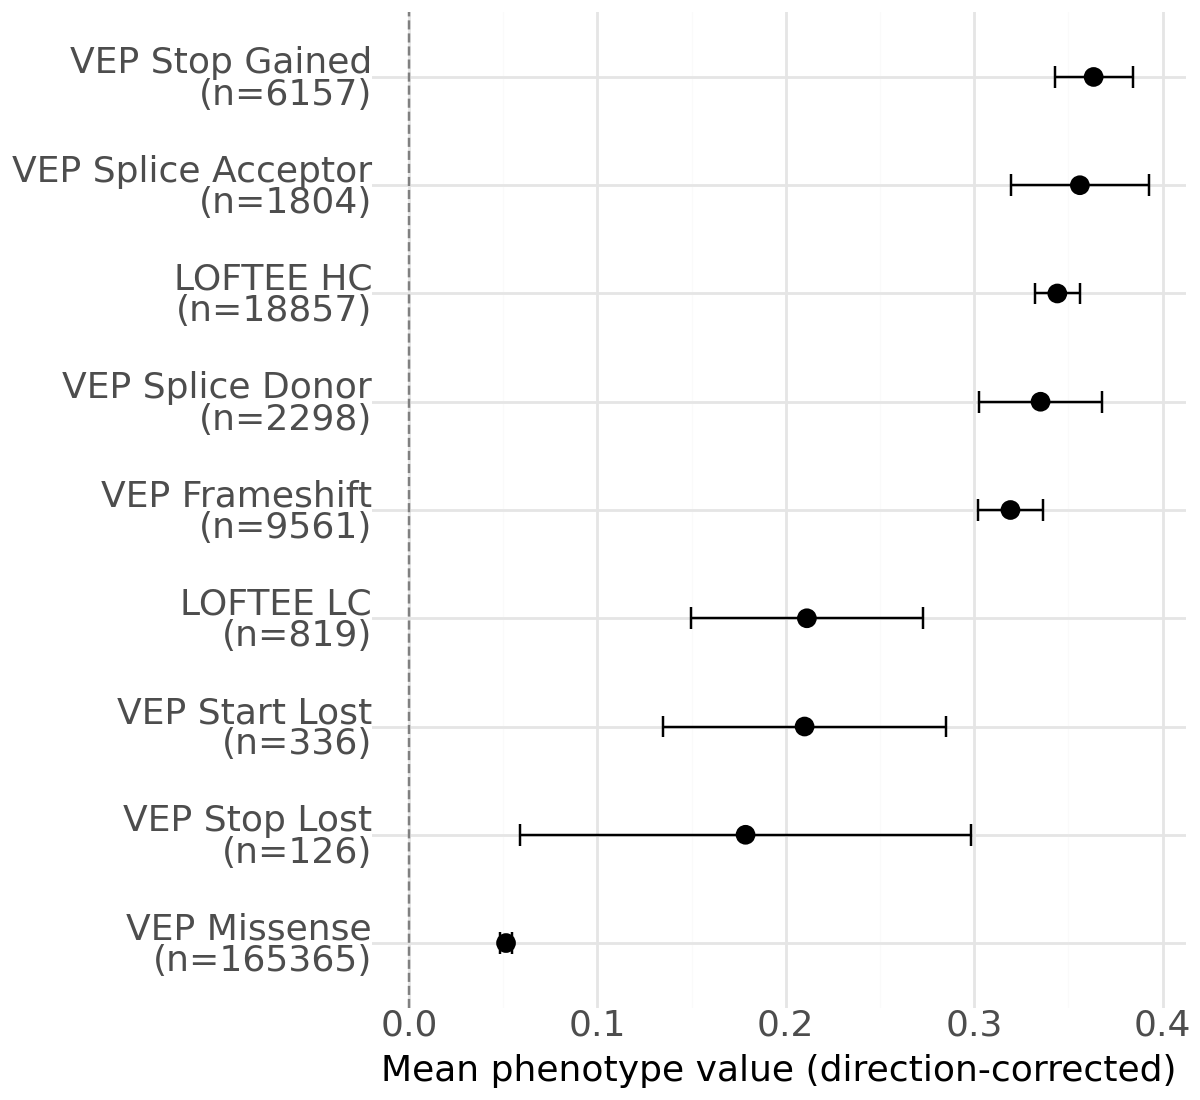

In [8]:
avg_plof_plot = (
    plof_pheno_df
    .join(
        anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .to_pandas()
)

avg_plof_plot['n_label'] = avg_plof_plot['label'] + '\n(n=' + avg_plof_plot['n_vars'].astype(str) + ')'

avg_plof_plot['n_label'] = pd.Categorical(
    avg_plof_plot['n_label'],
    categories=avg_plof_plot.sort_values('mean_pheno', ascending=True)['n_label'].unique(),
    ordered=True
)

(
    ggplot(
        avg_plof_plot,
        aes(x='n_label', y='mean_pheno')
    )
    + geom_hline(yintercept=0, linetype='dashed', color='grey')
    + geom_point(size=3)
    + geom_errorbar(
        aes(ymin='ci_low_pheno', ymax='ci_high_pheno'),
        width=0.2,
    )
    + labs(
        x='', 
        y='Mean phenotype value (direction-corrected)'
    )
    + coord_flip()
    + theme_minimal()
    + theme(
        figure_size=(6, 5.5),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

## Genome-wide scores

In [18]:
# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_odds.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
gnomw_anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

gnomw_anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""missense""","""am_pathogenicity""","""#FFCA28""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#FB8C00""","""ESM1v""",-1
"""missense""","""score_pai3d""","""#D84315""","""PrimateAI-3D""",1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""conservation""","""gpn_star_llr_calibrated_mean""","""#942c80""","""GPN-Star""",-1
…,…,…,…,…
"""splicing""","""absplice2_max""","""#26C6DA""","""AbSplice2 (max)""",1
"""regulatory_nondir""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",-1
"""regulatory_nondir""","""abexp_abs_max""","""#80CBC4""","""AbExp abs max""",1


In [19]:
gnomw_anno = pl.scan_parquet("/home/dnanexus/data_dir/genebass352genes_olink371genes_annotated_251205_fillna.parquet")

plof_annos = avg_plof_plot['annotation'].to_list()
selected_annos = ['gpn_star_llr_calibrated_mean', 'cadd_raw', 'verphylop'] #, 'abexp_abs_max']

gnomw_anno = (
    gnomw_anno
    .filter(
        # Choose CDS
        (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds') == True) | (pl.col('mane_cds') == True) | (pl.col('non_mane_cds') == True)) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region', 'gene_name'])
        .union(set(selected_annos))
        .union(set(plof_annos))
    )
    .collect(engine='streaming')

    .unpivot(
        index=set(['id', 'region', 'gene_name']).union(plof_annos),
        on=selected_annos,
        variable_name='annotation',
        value_name='annotation_score',
    )
    .unpivot(
        index = ['id', 'region', 'gene_name', 'annotation', 'annotation_score'],
        variable_name='plof_type',
        value_name='plof_score',
    )
    .filter(
        pl.col('plof_score') == 1
    )
    .join(
        gnomw_anno_config_df.drop('category').unique(), 
        on='annotation'
    )
    .join(
        anno_config_df.rename({
            'annotation':'plof_type', 
            'annotation_dir':'plof_dir',
            'label':'label_plof'
        }).select(['plof_type', 'plof_dir', 'label_plof']).unique(),
        on='plof_type'
    )
    .with_columns(
        annotation_score_dircorr = (pl.col("annotation_score")*pl.col("annotation_dir")).cast(pl.Float32),
    )
)

gnomw_anno


id,region,gene_name,annotation,annotation_score,plof_type,plof_score,color,label,annotation_dir,plof_dir,label_plof,annotation_score_dircorr
str,str,str,str,f32,str,i32,str,str,i8,i8,str,f32
"""chr20:3804961:A:G""","""ENSG00000101224""","""CDC25B""","""gpn_star_llr_calibrated_mean""",-8.790766,"""consequence_stop_lost""",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Stop Lost""",8.790766
"""chr16:2037982:T:C""","""ENSG00000065054""","""SLC9A3R2""","""gpn_star_llr_calibrated_mean""",-9.229596,"""consequence_stop_lost""",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Stop Lost""",9.229596
"""chr14:32154946:T:G""","""ENSG00000100852""","""ARHGAP5""","""gpn_star_llr_calibrated_mean""",-8.008554,"""consequence_stop_lost""",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Stop Lost""",8.008554
"""chr3:52524355:G:T""","""ENSG00000010327""","""STAB1""","""gpn_star_llr_calibrated_mean""",-8.240566,"""consequence_stop_lost""",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Stop Lost""",8.240566
"""chr3:52524354:T:C""","""ENSG00000010327""","""STAB1""","""gpn_star_llr_calibrated_mean""",-6.738814,"""consequence_stop_lost""",1,"""#942c80""","""GPN-Star""",-1,1,"""VEP Stop Lost""",6.738814
…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr17:39715823:C:T""","""ENSG00000141736""","""ERBB2""","""verphylop""",2.587,"""consequence_missense_variant""",1,"""#483D8B""","""Vertebrate PhyloP""",1,1,"""VEP Missense""",2.587
"""chr10:99819216:C:A""","""ENSG00000023839""","""ABCC2""","""verphylop""",7.101,"""consequence_missense_variant""",1,"""#483D8B""","""Vertebrate PhyloP""",1,1,"""VEP Missense""",7.101
"""chr10:99800490:A:T""","""ENSG00000023839""","""ABCC2""","""verphylop""",8.683,"""consequence_missense_variant""",1,"""#483D8B""","""Vertebrate PhyloP""",1,1,"""VEP Missense""",8.683


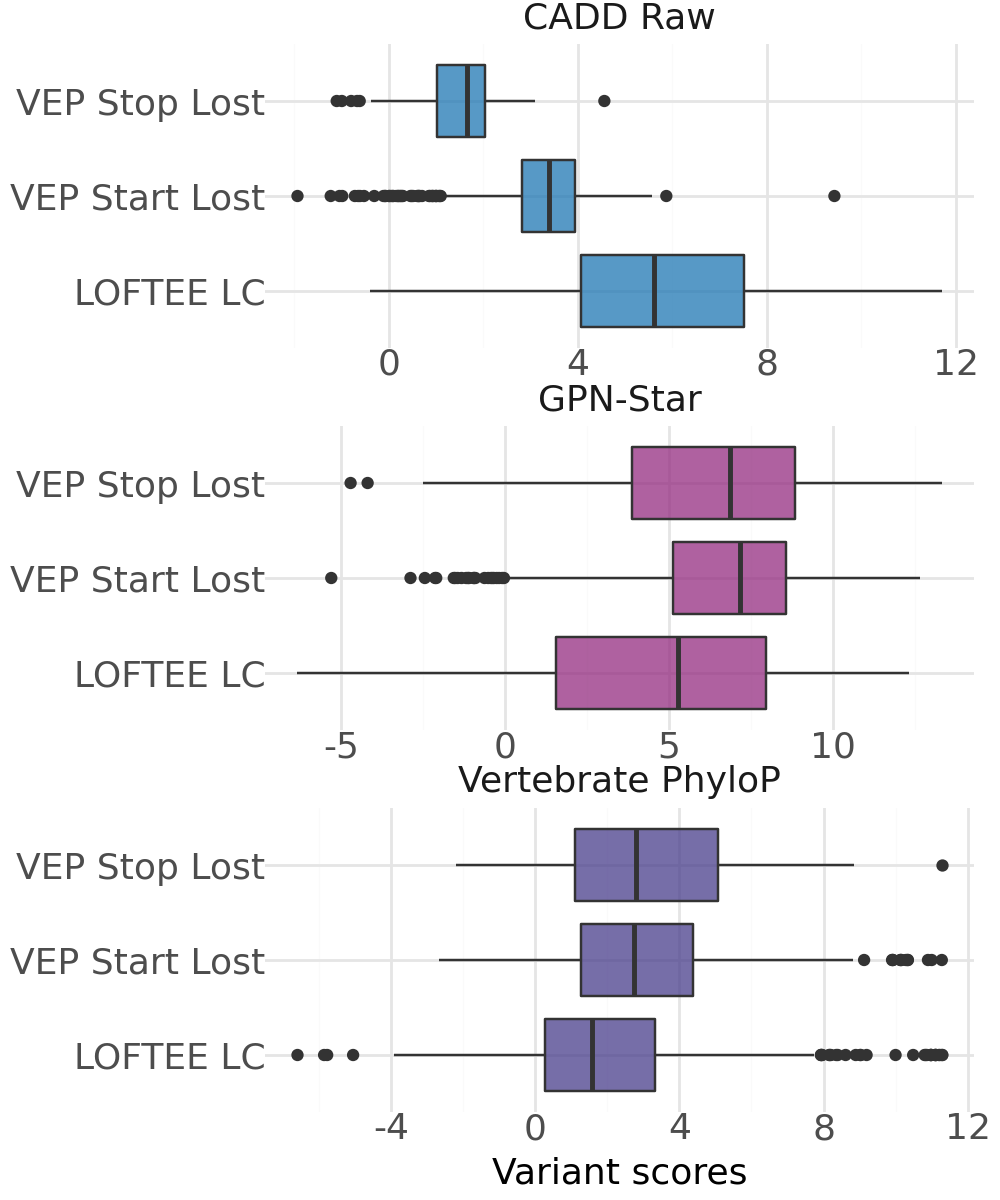

In [20]:
gnomw_anno_plot = gnomw_anno.filter(
    pl.col('plof_type').is_in(['loftee_lc', 'consequence_stop_lost', 'consequence_start_lost'])
)

color_dict = dict(zip(gnomw_anno_config_df['label'], gnomw_anno_config_df['color']))

(
    ggplot(
        gnomw_anno_plot,
        aes(y='annotation_score_dircorr', x='label_plof', fill='label')
    )
    + geom_boxplot(width=0.75, alpha=0.75)
    + facet_wrap('~label', scales='free_x', nrow=3)
    + scale_fill_manual(values=color_dict)
    + labs(
        x='',
        y='Variant scores'
    )
    + theme_minimal()
    + coord_flip()
    + theme(
        figure_size=(5, 6),
        legend_position='none',
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        strip_text=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)